<a href="https://colab.research.google.com/github/SamiraKheradmand/IASC-ASCE-Transformer-SHM/blob/main/notebooks/02_split_methods/chronological/Chronological_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [355]:
import os
import scipy.io as sio
from scipy.io.matlab._mio5_params import mat_struct
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from pathlib import Path
import re
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [356]:
SPLIT_SEED = 42
MODEL_SEED = 2026

In [357]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [358]:
!ls "/content/drive/MyDrive/ASCE_IASC/MAT_data"

shm01a.mat  shm03a.mat	shm05a.mat  shm07a.mat	shm09a.mat
shm02a.mat  shm04a.mat	shm06a.mat  shm08a.mat


In [359]:
from pathlib import Path

import numpy as np
import scipy.io as sio


# مسیر فایل‌ها
DATA_DIR = Path("/content/drive/MyDrive/ASCE_IASC/MAT_data")

# فقط 15 سنسور واقعی سازه
CHANNELS = [f"DA{i:02d}" for i in range(1, 16)]

# پیدا کردن فایل‌های 9 حالت سازه
mat_files = sorted(DATA_DIR.glob("shm*.mat"))

print("Folder exists:", DATA_DIR.exists())
print("Number of files:", len(mat_files))
print("Number of channels:", len(CHANNELS))


def load_ambient_file(file_path):
    """
    خواندن یک فایل Ambient از داده‌های IASC-ASCE
    """

    mat = sio.loadmat(file_path,squeeze_me=True,struct_as_record=False)

    dasy = mat["dasy"]
    dasy_dscr = mat["dasy_dscr"]
    fs = float(mat["fsdasy"])

    signals = []
    descriptions = []

    for i, channel in enumerate(CHANNELS, start=1):

        signal = np.asarray(getattr(dasy, channel)).reshape(-1)

        description_name = f"DAdscr{i:02d}"
        description = getattr(dasy_dscr, description_name)

        signals.append(signal)
        descriptions.append(description)

    # شکل خروجی:
    # (تعداد نمونه‌های زمانی، تعداد سنسورها)
    X_raw = np.column_stack(signals)

    return X_raw, fs, descriptions

Folder exists: True
Number of files: 9
Number of channels: 15


In [360]:
all_cases = {}
descriptions = [] # Initialize descriptions to an empty list

for file_path in mat_files:

    case_name = file_path.stem
    case_number = int(case_name[3:5])

    X_raw, fs, descriptions = load_ambient_file(file_path)

    all_cases[case_name] = {
        "X_raw": X_raw,
        "fs": fs,
        "channels": CHANNELS.copy(),
        "descriptions": descriptions,
        "case_number": case_number,
        "label": case_number - 1,
        "file_path": file_path
    }

    print(
        f"{case_name} | "
        f"shape: {X_raw.shape} | "
        f"fs: {fs} Hz | "
        f"label: {case_number - 1}"

    )
print( f"description: {pd.DataFrame(descriptions)}")

shm01a | shape: (60000, 15) | fs: 200.0 Hz | label: 0
shm02a | shape: (60000, 15) | fs: 200.0 Hz | label: 1
shm03a | shape: (60000, 15) | fs: 200.0 Hz | label: 2
shm04a | shape: (60000, 15) | fs: 200.0 Hz | label: 3
shm05a | shape: (60000, 15) | fs: 200.0 Hz | label: 4
shm06a | shape: (45568, 15) | fs: 200.0 Hz | label: 5
shm07a | shape: (180000, 15) | fs: 200.0 Hz | label: 6
shm08a | shape: (180000, 15) | fs: 200.0 Hz | label: 7
shm09a | shape: (180000, 15) | fs: 200.0 Hz | label: 8
description:                                                0
0   Base West side - EPI sensor X direction (N+)
1      Base Center - EPI sensor Y direction (W+)
2   Base East side - EPI sensor X direction (N+)
3    1st Floor - N/S EPI Sensor at West end (N+)
4      1st Floor - E/W FBA Sensor at Center (W+)
5    1st Floor - N/S FBA Sensor at East end (N+)
6    2nd Floor - N/S FBA Sensor at West end (N+)
7      2nd Floor - E/W EPI Sensor at Center (W+)
8    2nd Floor - N/S EPI Sensor at East end (N+)
9    3rd

In [361]:
RUN_TEST = False

In [362]:
# ============================================================
# Step 2: Chronological split and Butterworth high-pass filter
# Filter is applied separately to Train, Validation and Test
# ============================================================

import pandas as pd
from scipy.signal import butter, sosfiltfilt


# ----------------------------
# Split settings
# ----------------------------
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20

GAP_SEC = 0
EDGE_SEC = 2


# ----------------------------
# High-pass filter settings
# ----------------------------
CUTOFF = 0.1
ORDER = 2


def highpass_filter(X, fs):

    """
    Apply a Butterworth high-pass filter to all sensor channels.
    X shape:(samples, sensors)
    """

    sos = butter(N=ORDER, Wn=CUTOFF,btype="highpass",fs=fs,output="sos")
    X_filtered = sosfiltfilt(sos,X,axis=0)

    return X_filtered

In [363]:
train_data = {}
val_data = {}
test_data = {}

split_report = []

for case_name in sorted(all_cases.keys()):

    # Raw data
    X = all_cases[case_name]["X_raw"]
    fs = all_cases[case_name]["fs"]

    n_samples = len(X)

    gap_size = int(GAP_SEC * fs)
    edge_size = int(EDGE_SEC * fs)

    # ----------------------------
    # Chronological split boundaries
    # ----------------------------
    train_end = int(TRAIN_RATIO * n_samples)

    val_start = train_end + gap_size
    val_end = val_start + int(VAL_RATIO * n_samples)

    test_start = val_end + gap_size

    if test_start >= n_samples:
        raise ValueError(f"{case_name}: signal is too short for this gap.")

    # ----------------------------
    # Split raw signal
    # ----------------------------
    X_train_raw = X[:train_end]
    X_val_raw = X[val_start:val_end]
    X_test_raw = X[test_start:]

    # Check split lengths
    if min(len(X_train_raw), len(X_val_raw), len(X_test_raw)) <= 2 * edge_size:
        raise ValueError(f"{case_name}: EDGE_SEC is too large.")

    # ----------------------------
    # Filter each split separately
    # ----------------------------
    X_train_filtered = highpass_filter(X_train_raw, fs)
    X_val_filtered  = highpass_filter(X_val_raw, fs)
    X_test_filtered = highpass_filter(X_test_raw, fs)

    # ----------------------------
    # Remove filter edges
    # ----------------------------
    X_train_filtered = X_train_filtered[edge_size:-edge_size]
    X_val_filtered  = X_val_filtered[edge_size:-edge_size]
    X_test_filtered = X_test_filtered[edge_size:-edge_size]

    # ----------------------------
    # Save filtered data
    # ----------------------------
    train_data[case_name] = X_train_filtered
    val_data[case_name] = X_val_filtered
    test_data[case_name] = X_test_filtered

    split_report.append({
        "case": case_name,
        "total_samples": n_samples,

        "train_samples_filtered": len(X_train_filtered),
        "val_samples_filtered": len(X_val_filtered),
        "test_samples_filtered":len(X_test_filtered),
        "train_duration_sec":len(X_train_filtered) / fs,
        "val_duration_sec":len(X_val_filtered) / fs,
        "test_duration_sec":len(X_test_filtered) / fs
    })


split_report_df = pd.DataFrame(split_report)

display(split_report_df)

,case,total_samples,train_samples_filtered,val_samples_filtered,test_samples_filtered,train_duration_sec,val_duration_sec,test_duration_sec
0,shm01a,60000,35200,11200,11200,176.0,56.000,56.000
1,shm02a,60000,35200,11200,11200,176.0,56.000,56.000
2,shm03a,60000,35200,11200,11200,176.0,56.000,56.000
3,shm04a,60000,35200,11200,11200,176.0,56.000,56.000
4,shm05a,60000,35200,11200,11200,176.0,56.000,56.000
5,shm06a,45568,26540,8313,8315,132.7,41.565,41.575
6,shm07a,180000,107200,35200,35200,536.0,176.000,176.000
7,shm08a,180000,107200,35200,35200,536.0,176.000,176.000
8,shm09a,180000,107200,35200,35200,536.0,176.000,176.000


In [364]:
for case_name in sorted(train_data.keys()):

    print(f"{case_name} | "
          f"Train: {train_data[case_name].shape} | "
          f"Validation: {val_data[case_name].shape} | "
          f"Test: {test_data[case_name].shape}" )

shm01a | Train: (35200, 15) | Validation: (11200, 15) | Test: (11200, 15)
shm02a | Train: (35200, 15) | Validation: (11200, 15) | Test: (11200, 15)
shm03a | Train: (35200, 15) | Validation: (11200, 15) | Test: (11200, 15)
shm04a | Train: (35200, 15) | Validation: (11200, 15) | Test: (11200, 15)
shm05a | Train: (35200, 15) | Validation: (11200, 15) | Test: (11200, 15)
shm06a | Train: (26540, 15) | Validation: (8313, 15) | Test: (8315, 15)
shm07a | Train: (107200, 15) | Validation: (35200, 15) | Test: (35200, 15)
shm08a | Train: (107200, 15) | Validation: (35200, 15) | Test: (35200, 15)
shm09a | Train: (107200, 15) | Validation: (35200, 15) | Test: (35200, 15)


In [365]:
filter_check = []

for case_name in sorted(all_cases.keys()):

    raw_train_end = int(TRAIN_RATIO * len(all_cases[case_name]["X_raw"]))
    X_train_raw = all_cases[case_name]["X_raw"][:raw_train_end]
    X_train_filtered = train_data[case_name]

    filter_check.append({
        "case": case_name,
        "mean_abs_raw": np.mean(np.abs(np.mean(X_train_raw, axis=0))),
        "mean_abs_filtered": np.mean(np.abs(np.mean(X_train_filtered,axis=0)))
    })

filter_check_df = pd.DataFrame(filter_check)
display(filter_check_df)

,case,mean_abs_raw,mean_abs_filtered
0,shm01a,0.001260,1.125002e-06
1,shm02a,0.001564,2.848653e-07
2,shm03a,0.000955,3.674356e-07
3,shm04a,0.001096,3.553501e-07
4,shm05a,0.001285,8.238489e-07
5,shm06a,0.001239,2.023264e-06
6,shm07a,0.001139,9.591543e-08
7,shm08a,0.001083,9.232525e-08
8,shm09a,0.001077,1.732560e-07


In [366]:
# ============================================================
# Step 3: Select sensor channels
# ============================================================

# selected_sensor_indices = [8, 11, 13, 14]  # DA09, DA12, DA14, DA15
# selected_sensor_indices = [0,3]
selected_sensor_indices = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14]

selected_sensor_names = [CHANNELS[i] for i in selected_sensor_indices]

train_selected = {}
val_selected = {}
test_selected = {}

for case_name in train_data.keys():
    train_selected[case_name] = train_data[case_name][:, selected_sensor_indices]
    val_selected[case_name]   = val_data[case_name][:, selected_sensor_indices]
    test_selected[case_name]  = test_data[case_name][:, selected_sensor_indices]

print("Selected sensors:", selected_sensor_names)

for case_name in sorted(train_selected.keys()):
    print(
        f"Case {case_name}: "
        f"train={train_selected[case_name].shape}, "
        f"val={val_selected[case_name].shape}, "
        f"test={test_selected[case_name].shape}"
    )

Selected sensors: ['DA01', 'DA02', 'DA03', 'DA04', 'DA05', 'DA06', 'DA07', 'DA08', 'DA09', 'DA10', 'DA11', 'DA12', 'DA13', 'DA14', 'DA15']
Case shm01a: train=(35200, 15), val=(11200, 15), test=(11200, 15)
Case shm02a: train=(35200, 15), val=(11200, 15), test=(11200, 15)
Case shm03a: train=(35200, 15), val=(11200, 15), test=(11200, 15)
Case shm04a: train=(35200, 15), val=(11200, 15), test=(11200, 15)
Case shm05a: train=(35200, 15), val=(11200, 15), test=(11200, 15)
Case shm06a: train=(26540, 15), val=(8313, 15), test=(8315, 15)
Case shm07a: train=(107200, 15), val=(35200, 15), test=(35200, 15)
Case shm08a: train=(107200, 15), val=(35200, 15), test=(35200, 15)
Case shm09a: train=(107200, 15), val=(35200, 15), test=(35200, 15)


In [367]:
# ============================================================
# Step 4: Global train-based normalization
# One mean and standard deviation for each selected sensor
# ============================================================

EPS = 1e-8
train_concat = np.concatenate(
    [train_selected[case_name] for case_name in sorted(train_selected.keys())],axis=0)


print("Combined Train shape:", train_concat.shape)
train_mean = train_concat.mean(axis=0,keepdims=True,dtype=np.float64)
train_std = train_concat.std(axis=0,keepdims=True,dtype=np.float64)


# Prevent division by zero
train_std_safe = np.where(train_std < EPS,1.0,train_std)


print("Train mean shape:", train_mean.shape)
print("Train std shape:", train_std_safe.shape)

Combined Train shape: (524140, 15)
Train mean shape: (1, 15)
Train std shape: (1, 15)


In [368]:
train_norm = {}
val_norm = {}
test_norm = {}


for case_name in sorted(train_selected.keys()):

    train_norm[case_name] = ((train_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)
    val_norm[case_name]   = ((val_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)
    test_norm[case_name]  = ((test_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)


print("Normalization completed.")

Normalization completed.


In [369]:
train_norm_concat = np.concatenate(
    [ train_norm[case_name] for case_name in sorted(train_norm.keys())],axis=0)

normalized_train_mean = train_norm_concat.mean(axis=0)
normalized_train_std = train_norm_concat.std(axis=0)

print("Train mean after normalization:")
print(np.round(normalized_train_mean,5))

print("\nTrain std after normalization:")
print(np.round(normalized_train_std,5))

Train mean after normalization:
[ 0.  0. -0. -0.  0.  0. -0. -0.  0. -0.  0.  0.  0. -0.  0.]

Train std after normalization:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [370]:
# ============================================================
# Experiment configuration
# Chronological Split + High-pass + Raw 1D-CNN
# ============================================================

EXPERIMENT_NAME = "Chronological_Highpass_RawCNN_12Sensors"
MODEL_NAME = "Raw 1D-CNN"

BATCH_SIZE = 64

CUTOFF = 0.10
FILTER_ORDER = 2


RUN_TEST = False

In [371]:
# ============================================================
# Step 5: Create non-overlapping time windows
# ============================================================

WINDOW_SIZE = 512
STEP_SIZE = 512

FS_DASY = 200

print("Window size:", WINDOW_SIZE, "samples")
print("Window duration:", WINDOW_SIZE / FS_DASY, "seconds")
print("Step size:", STEP_SIZE, "samples")
print("Step duration:", STEP_SIZE / FS_DASY, "seconds")

Window size: 512 samples
Window duration: 2.56 seconds
Step size: 512 samples
Step duration: 2.56 seconds


In [372]:
def make_windows(split_data):
    """
    Convert continuous signals of each scenario into fixed-length windows.
    Input:
        split_data[case_name]
        shape = (samples, selected_sensors)

    Output:
        X_windows shape = (number_of_windows, window_size, selected_sensors)
        y_labels shape = (number_of_windows,)
    """

    all_windows = []
    all_labels = []
    meta_rows = []

    for case_name in sorted(split_data.keys()):

        X = split_data[case_name]

        n_samples = len(X)

        # shm01a -> scenario 1 -> label 0
        scenario_number = int(case_name[3:5])
        label = scenario_number - 1

        window_number = 0

        for start in range(0, n_samples - WINDOW_SIZE + 1,STEP_SIZE):

            end = start + WINDOW_SIZE

            window = X[start:end, :]

            all_windows.append(window)
            all_labels.append(label)

            meta_rows.append({
                "case": case_name,
                "scenario": scenario_number,
                "label": label,
                "window": window_number,
                "start_sample": start,
                "end_sample": end
            })

            window_number += 1

    if len(all_windows) == 0:
        raise ValueError("No windows were created.")

    X_windows = np.stack(all_windows,axis=0).astype(np.float32)

    y_labels = np.array(all_labels,dtype=np.int64)

    meta_df = pd.DataFrame(meta_rows)

    return X_windows, y_labels, meta_df

In [373]:
X_train, y_train, train_meta_df = make_windows(train_norm)

X_val, y_val, val_meta_df = make_windows(val_norm)

X_test, y_test, test_meta_df = make_windows(test_norm)

In [374]:
print("Window shapes:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\nLabel shapes:")
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

Window shapes:
X_train: (1018, 512, 15)
X_val:   (325, 512, 15)
X_test:  (325, 512, 15)

Label shapes:
y_train: (1018,)
y_val:   (325,)
y_test:  (325,)


In [375]:
print("\nTrain class counts:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation class counts:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest class counts:")
print(pd.Series(y_test).value_counts().sort_index())


Train class counts:
0     68
1     68
2     68
3     68
4     68
5     51
6    209
7    209
8    209
Name: count, dtype: int64

Validation class counts:
0    21
1    21
2    21
3    21
4    21
5    16
6    68
7    68
8    68
Name: count, dtype: int64

Test class counts:
0    21
1    21
2    21
3    21
4    21
5    16
6    68
7    68
8    68
Name: count, dtype: int64


In [376]:
import numpy as np
import torch

from torch.utils.data import TensorDataset, DataLoader


# ----------------------------
# بررسی داده‌ها قبل از Tensor
# ----------------------------
print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:  ", y_val.shape)
print("y_test shape: ", y_test.shape)


# تعداد داده و برچسب باید برابر باشد
assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

# بررسی NaN و Inf
assert np.isfinite(X_train).all(), "X_train contains NaN or Inf."
assert np.isfinite(X_val).all(), "X_val contains NaN or Inf."
assert np.isfinite(X_test).all(), "X_test contains NaN or Inf."

print("Data check completed.")

X_train shape: (1018, 512, 15)
X_val shape:   (325, 512, 15)
X_test shape:  (325, 512, 15)
y_train shape: (1018,)
y_val shape:   (325,)
y_test shape:  (325,)
Data check completed.


In [377]:
# ============================================================
# Step 6: Convert arrays to PyTorch tensors
# ============================================================

import random
import numpy as np
import torch

from torch.utils.data import TensorDataset, DataLoader


# ----------------------------
# Reproducibility
# ----------------------------
# MODEL_SEEDS = [42, 7, 123, 2026]

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Reproducibility for CUDA
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Warn if a nondeterministic operation is used
    torch.use_deterministic_algorithms(True,warn_only=True)

set_seed(MODEL_SEED)
print("Training seed:", MODEL_SEED)

# Inputs must be float32
X_train_tensor = torch.from_numpy(X_train.astype(np.float32, copy=False))
X_val_tensor = torch.from_numpy(X_val.astype(np.float32, copy=False))
X_test_tensor = torch.from_numpy(X_test.astype(np.float32, copy=False))


# Labels for CrossEntropyLoss must be int64
y_train_tensor = torch.from_numpy(y_train.astype(np.int64, copy=False))
y_val_tensor = torch.from_numpy(y_val.astype(np.int64, copy=False))
y_test_tensor = torch.from_numpy(y_test.astype(np.int64, copy=False))


print("\nTensor shapes:")
print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)

print("X_val_tensor:", X_val_tensor.shape)
print("y_val_tensor:", y_val_tensor.shape)

print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

Training seed: 2026

Tensor shapes:
X_train_tensor: torch.Size([1018, 512, 15])
y_train_tensor: torch.Size([1018])
X_val_tensor: torch.Size([325, 512, 15])
y_val_tensor: torch.Size([325])
X_test_tensor: torch.Size([325, 512, 15])
y_test_tensor: torch.Size([325])


In [378]:
# ============================================================
# Create Dataset and DataLoader
# ============================================================

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor,y_test_tensor)

BATCH_SIZE = 64
loader_generator = torch.Generator()
loader_generator.manual_seed(MODEL_SEED)

train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,generator=loader_generator)
val_loader   = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)
test_loader  = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False)

In [379]:
print("Number of train samples:", len(train_dataset))
print("Number of val samples:  ", len(val_dataset))
print("Number of test samples: ", len(test_dataset))

print("\nNumber of train batches:", len(train_loader))
print("Number of val batches:  ", len(val_loader))
print("Number of test batches: ", len(test_loader))


X_batch, y_batch = next(iter(train_loader))

print("\nOne train batch:")
print("X_batch shape:", X_batch.shape)
print("y_batch shape:", y_batch.shape)
print("First 10 labels:", y_batch[:10])

Number of train samples: 1018
Number of val samples:   325
Number of test samples:  325

Number of train batches: 16
Number of val batches:   6
Number of test batches:  6

One train batch:
X_batch shape: torch.Size([64, 512, 15])
y_batch shape: torch.Size([64])
First 10 labels: tensor([7, 8, 6, 4, 7, 7, 8, 7, 1, 8])


In [380]:
# ============================================================
# Step 7: Define Raw 1D-CNN
# Input shape: (batch, time, sensors)
# ============================================================

import torch.nn as nn


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

INPUT_CHANNELS = X_train_tensor.shape[2]
NUM_CLASSES = 9


class RawCNN1D(nn.Module):

    def __init__(
        self,
        input_channels,
        num_classes,
        dropout=0.10
    ):
        super().__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv1d(
                input_channels,
                32,
                kernel_size=7,
                padding=3
            ),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv1d(
                32,
                64,
                kernel_size=5,
                padding=2
            ),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv1d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.dropout = nn.Dropout(
            dropout
        )

        self.classifier = nn.Linear(
            128,
            num_classes
        )


    def forward(self, x):

        # (batch, time, sensors)
        # ->
        # (batch, sensors, time)

        x = x.transpose(1, 2)

        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)

        x = self.pool(x)
        x = x.squeeze(-1)

        x = self.dropout(x)

        return self.classifier(x)


set_seed(MODEL_SEED)

model = RawCNN1D(
    input_channels=INPUT_CHANNELS,
    num_classes=NUM_CLASSES,
    dropout=0.10
).to(device)


print("Device:", device)
print("Input channels:", INPUT_CHANNELS)
print("Number of classes:", NUM_CLASSES)
print(model)

Device: cpu
Input channels: 15
Number of classes: 9
RawCNN1D(
  (conv_block1): Sequential(
    (0): Conv1d(15, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (pool): AdaptiveAvgPool1d(output_size=1)
  (dropout): Dropout(p=0.1, inplace=False)
  (classifier): Linear(in_features=128, out_features=9, bias=

In [381]:
# ============================================================
# Step 8: Loss function and optimizer
# ============================================================

class_counts = torch.bincount(y_train_tensor, minlength=NUM_CLASSES).float()
if torch.any(class_counts == 0):
    raise ValueError("At least one class has no training samples.")

class_weights = (len(y_train_tensor) / (NUM_CLASSES * class_counts))
class_weights = class_weights.to(device)

print("Class counts and weights:")

for class_id in range(NUM_CLASSES):

    print(
        f"Scenario {class_id + 1} | "
        f"count: {int(class_counts[class_id])} | "
        f"weight: {class_weights[class_id].item():.4f}"
    )

Class counts and weights:
Scenario 1 | count: 68 | weight: 1.6634
Scenario 2 | count: 68 | weight: 1.6634
Scenario 3 | count: 68 | weight: 1.6634
Scenario 4 | count: 68 | weight: 1.6634
Scenario 5 | count: 68 | weight: 1.6634
Scenario 6 | count: 51 | weight: 2.2179
Scenario 7 | count: 209 | weight: 0.5412
Scenario 8 | count: 209 | weight: 0.5412
Scenario 9 | count: 209 | weight: 0.5412


In [382]:
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", LEARNING_RATE)

Loss function: CrossEntropyLoss()
Optimizer: AdamW
Learning rate: 0.0002


In [383]:
# ============================================================
# Step 9: Train cnn
# Best model selection based on Validation Macro-F1
# ============================================================

from sklearn.metrics import accuracy_score, f1_score
import copy
import torch

NUM_EPOCHS = 100
PATIENCE = 20
GRAD_CLIP = 1.0
MIN_DELTA = 1e-4

LABELS_ORDER = np.arange(NUM_CLASSES)

cnn_history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "train_macro_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_macro_f1": [],
}

best_val_macro_f1 = -1.0
best_epoch = 0
best_model_state = None
epochs_without_improvement = 0


def run_one_epoch_cnn(model, data_loader, criterion, optimizer=None, device="cpu"):
    """
    If optimizer is given: training mode
    If optimizer is None: evaluation mode
    """

    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for xb, yb in data_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            logits = model(xb)
            loss = criterion(logits, yb)

            if is_training:
                loss.backward()

                # Gradient clipping helps Transformer training stability
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)

                optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.detach().cpu())
        all_labels.append(yb.detach().cpu())

    avg_loss = total_loss / len(data_loader.dataset)
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return avg_loss, acc, macro_f1


for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc, train_macro_f1 = run_one_epoch_cnn(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_acc, val_macro_f1 = run_one_epoch_cnn(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        optimizer=None,
        device=device
    )

    cnn_history["epoch"].append(epoch)
    cnn_history["train_loss"].append(train_loss)
    cnn_history["train_acc"].append(train_acc)
    cnn_history["train_macro_f1"].append(train_macro_f1)
    cnn_history["val_loss"].append(val_loss)
    cnn_history["val_acc"].append(val_acc)
    cnn_history["val_macro_f1"].append(val_macro_f1)

    # Save best model based on validation Macro-F1
    if val_macro_f1 > best_val_macro_f1 + MIN_DELTA:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Train Macro-F1: {train_macro_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val Macro-F1: {val_macro_f1:.4f}"
        )

    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break



Epoch 001 | Train Loss: 1.8895 | Train Acc: 0.3546 | Train Macro-F1: 0.3465 | Val Loss: 1.9961 | Val Acc: 0.3754 | Val Macro-F1: 0.3163
Epoch 005 | Train Loss: 0.9489 | Train Acc: 0.8360 | Train Macro-F1: 0.8514 | Val Loss: 1.0721 | Val Acc: 0.8246 | Val Macro-F1: 0.8340
Epoch 010 | Train Loss: 0.4696 | Train Acc: 0.9224 | Train Macro-F1: 0.9512 | Val Loss: 0.5338 | Val Acc: 0.9169 | Val Macro-F1: 0.9539
Epoch 015 | Train Loss: 0.2380 | Train Acc: 0.9686 | Train Macro-F1: 0.9802 | Val Loss: 0.2310 | Val Acc: 0.9938 | Val Macro-F1: 0.9967
Epoch 020 | Train Loss: 0.1222 | Train Acc: 0.9745 | Train Macro-F1: 0.9856 | Val Loss: 0.1062 | Val Acc: 0.9969 | Val Macro-F1: 0.9984
Epoch 025 | Train Loss: 0.0824 | Train Acc: 0.9843 | Train Macro-F1: 0.9909 | Val Loss: 0.0677 | Val Acc: 0.9969 | Val Macro-F1: 0.9984
Epoch 030 | Train Loss: 0.0579 | Train Acc: 0.9902 | Train Macro-F1: 0.9947 | Val Loss: 0.0466 | Val Acc: 1.0000 | Val Macro-F1: 1.0000
Epoch 035 | Train Loss: 0.0420 | Train Acc: 0.99

In [384]:
if best_model_state is None:
    raise RuntimeError("No best model was saved.")

model.load_state_dict(best_model_state)

print("\nTraining finished.")
print("Best epoch:",best_epoch)
print("Best validation Macro-F1:",best_val_macro_f1)


Training finished.
Best epoch: 26
Best validation Macro-F1: 1.0


In [385]:
# ============================================================
# Final evaluation control
# ============================================================

# Keep False during development/tuning.
# Set True only for final test evaluation.
RUN_TEST = False

In [386]:
# ============================================================
# Final evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

import pandas as pd
import torch


train_eval_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


def predict_with_model_cnn(
    model,
    data_loader,
    device="cpu"
):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for xb, yb in data_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            preds = torch.argmax(logits,dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(yb.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return all_labels, all_preds


def final_evaluate_cnn(
    model,
    data_loader,
    split_name,
    device="cpu"
):

    y_true, y_pred = predict_with_model_cnn(
        model=model,
        data_loader=data_loader,
        device=device
    )

    acc = accuracy_score(
        y_true,
        y_pred
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"\n===== {split_name} =====")
    print(f"Accuracy:    {acc:.4f}")
    print(f"Macro-F1:    {macro_f1:.4f}")
    print(f"Weighted-F1: {weighted_f1:.4f}")

    return {
        "split": split_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_true": y_true,
        "y_pred": y_pred
    }

In [387]:
model.eval()

cnn_train_results = final_evaluate_cnn(model,train_eval_loader,"TRAIN", device=device)
cnn_val_results = final_evaluate_cnn(model,val_loader,"VALIDATION",device=device)
test_results = final_evaluate_cnn(model,test_loader,"TEST",device)


===== TRAIN =====
Accuracy:    0.9853
Macro-F1:    0.9920
Weighted-F1: 0.9853

===== VALIDATION =====
Accuracy:    1.0000
Macro-F1:    1.0000
Weighted-F1: 1.0000

===== TEST =====
Accuracy:    0.9754
Macro-F1:    0.9721
Weighted-F1: 0.9753


In [388]:
cnn_test_results = None

if RUN_TEST:

    cnn_test_results = final_evaluate_cnn(
        model,
        test_loader,
        "TEST",
        device=device
    )

else:

    print("\nTest evaluation skipped.")


Test evaluation skipped.


In [389]:
summary_rows = [
    {
        "model": "Raw cnn",
        "preprocessing":
            "Butterworth high-pass + Train-based normalization",
        "selected_sensors":
            len(selected_sensor_names),
        "split":
            cnn_train_results["split"],
        "accuracy":
            cnn_train_results["accuracy"],
        "macro_f1":
            cnn_train_results["macro_f1"],
        "weighted_f1":
           cnn_train_results["weighted_f1"]
    },

    {
        "model": "Raw Transformer",
        "preprocessing":
            "Butterworth high-pass + Train-based normalization",
        "selected_sensors":
            len(selected_sensor_names),
        "split":
            cnn_val_results["split"],
        "accuracy":
            cnn_val_results["accuracy"],
        "macro_f1":
            cnn_val_results["macro_f1"],
        "weighted_f1":
            cnn_val_results["weighted_f1"]
    }
]

In [390]:
if RUN_TEST:

    summary_rows.append(
        {
            "model": "Raw cnn",
            "preprocessing":
                "Butterworth high-pass + Train-based normalization",
            "selected_sensors":
                len(selected_sensor_names),
            "split":
                cnn_test_results["split"],
            "accuracy":
                cnn_test_results["accuracy"],
            "macro_f1":
                cnn_test_results["macro_f1"],
            "weighted_f1":
                cnn_test_results["weighted_f1"]
        }
    )

In [391]:
cnn_summary_results = pd.DataFrame(
    summary_rows
)

display(
    cnn_summary_results
)

,model,preprocessing,selected_sensors,split,accuracy,macro_f1,weighted_f1
0,Raw cnn,Butterworth high-pass + Train-based normalization,15,TRAIN,0.985265,0.992022,0.985258
1,Raw Transformer,Butterworth high-pass + Train-based normalization,15,VALIDATION,1.000000,1.000000,1.000000


In [392]:
# ============================================================
# Step 11: Test confusion matrix
# ============================================================


if RUN_TEST:

    y_true_test = (
        cnn_test_results["y_true"]
    )

    y_pred_test = (
        cnn_test_results["y_pred"]
    )

    cm_cnn_test = confusion_matrix(
        y_true_test,
        y_pred_test,
        labels=np.arange(NUM_CLASSES)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_cnn_test,
        display_labels=[
            f"S{i+1}"
            for i in range(NUM_CLASSES)
        ]
    )

    disp.plot(
        values_format="d",
        cmap="Blues",
        colorbar=False
    )

    plt.title(
        "Test Confusion Matrix"
    )

    plt.grid(False)
    plt.show()

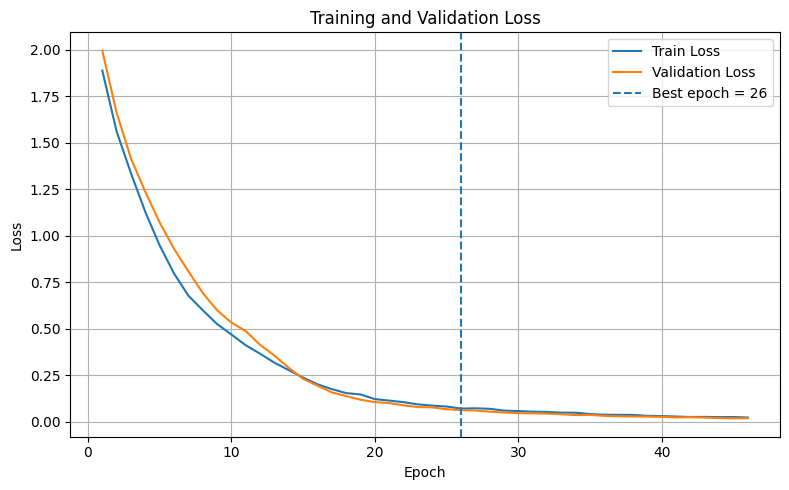

In [393]:
# ============================================================
# Step 12: Training curves
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history["epoch"],
    cnn_history["train_loss"],
    label="Train Loss"
)

plt.plot(
    cnn_history["epoch"],
    cnn_history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

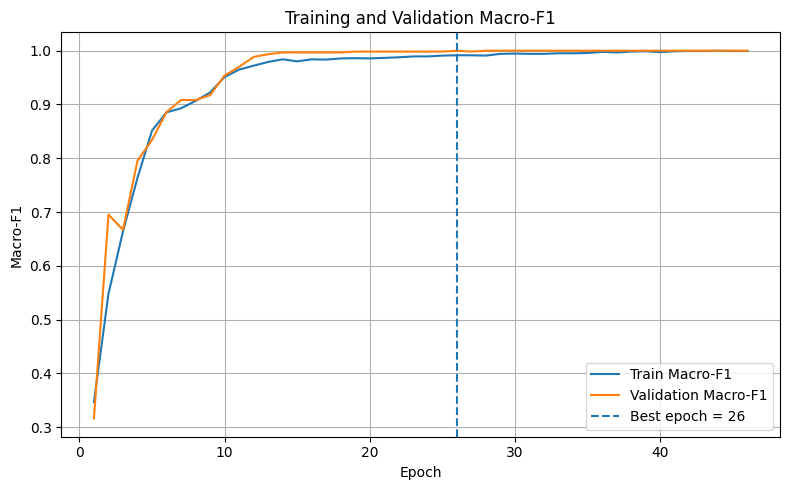

In [394]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history["epoch"],
    cnn_history["train_macro_f1"],
    label="Train Macro-F1"
)

plt.plot(
    cnn_history["epoch"],
    cnn_history["val_macro_f1"],
    label="Validation Macro-F1"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("Training and Validation Macro-F1")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()